In [1]:
import pandas as pd

In [2]:
data=pd.DataFrame({
    'age':[25,30,35,40,45],
    'salary':[5000,6000,7000,8000,9000],
    'country_code':[1,1,1,1,1]
})
data

,age,salary,country_code
0,25,5000,1
1,30,6000,1
2,35,7000,1
3,40,8000,1
4,45,9000,1


In [3]:
from sklearn.feature_selection import VarianceThreshold
selector=VarianceThreshold(threshold=0.1)
selected_data=selector.fit_transform(data)
selected_features=data.columns[selector.get_support()]
print("Selected Features:",selected_features)

Selected Features: Index(['age', 'salary'], dtype='object')


In [ ]:
data = pd.DataFrame({
    "Age": [25, 45, 35, 50, 40],
    "Blood_Pressure": [120, 140, 130, 150, 135],
    "Cholesterol": [180, 220, 200, 240, 210],
    "Gender": [0, 1, 1, 0, 1],          
    "Country_Code": ["India", "India", "India", "India", "India"],
    "Hospital_ID": [101, 101, 101, 101, 101],
    "Machine_Version": ["v2.1", "v2.1", "v2.1", "v2.1", "v2.2"]
})

data

,Age,Blood_Pressure,Cholesterol,Gender,Country_Code,Hospital_ID,Machine_Version
0,25,120,180,0,India,101,v2.1
1,45,140,220,1,India,101,v2.1
2,35,130,200,1,India,101,v2.1
3,50,150,240,0,India,101,v2.1
4,40,135,210,1,India,101,v2.2


In [6]:
data_encoded = pd.get_dummies(data, drop_first=True)


In [7]:
selector = VarianceThreshold(threshold=0.01)

selected_array = selector.fit_transform(data_encoded)

selected_features = data_encoded.columns[selector.get_support()]

print("\nSelected Features:")
print(selected_features)

selected_data = pd.DataFrame(selected_array, columns=selected_features)

print("\nFinal Dataset After Feature Selection:")
print(selected_data)



Selected Features:
Index(['Age', 'Blood_Pressure', 'Cholesterol', 'Gender',
       'Machine_Version_v2.2'],
      dtype='object')

Final Dataset After Feature Selection:
   Age  Blood_Pressure  Cholesterol  Gender  Machine_Version_v2.2
0   25             120          180       0                     0
1   45             140          220       1                     0
2   35             130          200       1                     0
3   50             150          240       0                     0
4   40             135          210       1                     1


In [8]:
data = pd.DataFrame({
    "size_sqft": [1000, 1500, 2000, 2500, 3000],
    "titles_count": [1, 2, 3, 4, 5],
    "price": [200000, 300000, 400000, 500000, 600000]
})
data

,size_sqft,titles_count,price
0,1000,1,200000
1,1500,2,300000
2,2000,3,400000
3,2500,4,500000
4,3000,5,600000


In [9]:
correlation_matrix=data.corr()
print(correlation_matrix)

              size_sqft  titles_count  price
size_sqft           1.0           1.0    1.0
titles_count        1.0           1.0    1.0
price               1.0           1.0    1.0


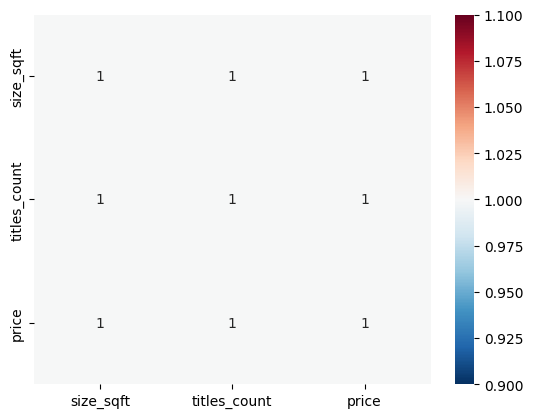

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(correlation_matrix,annot=True,cmap='RdBu_r')
plt.show()

In [12]:
import numpy as np

In [13]:
upper=correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
)
to_drop=[column for column in upper.columns if any(upper[column]>0.9)]
print("Highly Correlated Fatured to Drop:",to_drop)

Highly Correlated Fatured to Drop: ['titles_count', 'price']


In [19]:
data = pd.DataFrame({
    "house_size_sqft": [1000, 1500, 2000, 2500, 3000],
    "num_tiles": [200, 300, 400, 500, 600],
    "construction_cost": [200000, 300000, 400000, 500000, 600000],
    "bedrooms": [2, 3, 3, 4, 4],
    "market_price": [250000, 350000, 450000, 550000, 650000]
})
data

,house_size_sqft,num_tiles,construction_cost,bedrooms,market_price
0,1000,200,200000,2,250000
1,1500,300,300000,3,350000
2,2000,400,400000,3,450000
3,2500,500,500000,4,550000
4,3000,600,600000,4,650000


In [20]:
correlation_matrix = data.corr()
print("\nCorrelation Matrix:\n", correlation_matrix)


Correlation Matrix:
                    house_size_sqft  num_tiles  construction_cost  bedrooms  \
house_size_sqft           1.000000   1.000000           1.000000  0.944911   
num_tiles                 1.000000   1.000000           1.000000  0.944911   
construction_cost         1.000000   1.000000           1.000000  0.944911   
bedrooms                  0.944911   0.944911           0.944911  1.000000   
market_price              1.000000   1.000000           1.000000  0.944911   

                   market_price  
house_size_sqft        1.000000  
num_tiles              1.000000  
construction_cost      1.000000  
bedrooms               0.944911  
market_price           1.000000  


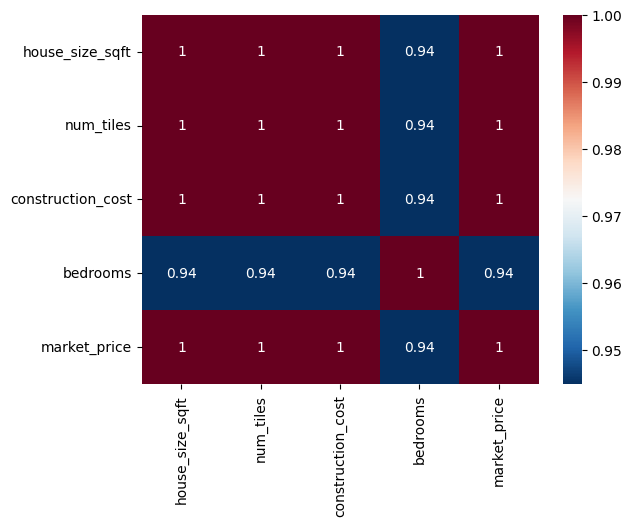

In [21]:
sns.heatmap(correlation_matrix, annot=True, cmap="RdBu_r")
plt.show()

In [23]:
#Chi-Square test

In [24]:
X=pd.DataFrame({
    'gender':[0,1,0,1,1],
    'married':[1,1,0,0,1],
    'income':[20000,40000,50000,30000,60000]
})
y=[0,1,1,0,1]
X

,gender,married,income
0,0,1,20000
1,1,1,40000
2,0,0,50000
3,1,0,30000
4,1,1,60000


In [25]:
#CHI-Square Requires non-negative values
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import MinMaxScaler

scalar=MinMaxScaler()
X_scaled=scalar.fit_transform(X)

selector=SelectKBest(score_func=chi2,k=2)
X_new=selector.fit_transform(X_scaled,y)

selected_features=X.columns[selector.get_support()]
print("Selected Features:",selected_features)

Selected Features: Index(['married', 'income'], dtype='object')


In [26]:
data = pd.DataFrame({
    "Gender": ["Male", "Female", "Male", "Female", "Male"],
    "Marital_Status": ["Yes", "No", "Yes", "Yes", "No"],
    "Education": ["Graduate", "Non-Graduate", "Graduate", "Graduate", "Non-Graduate"],
    "Applicant_Income": [5000, 3000, 4000, 6000, 3500],
    "Property_Area": ["Urban", "Rural", "Urban", "Urban", "Rural"],
    "Favorite_Color": ["Red", "Blue", "Green", "Red", "Blue"],
    "Loan_Status": ["Approved", "Rejected", "Approved", "Approved", "Rejected"]
})
data

,Gender,Marital_Status,Education,Applicant_Income,Property_Area,Favorite_Color,Loan_Status
0,Male,Yes,Graduate,5000,Urban,Red,Approved
1,Female,No,Non-Graduate,3000,Rural,Blue,Rejected
2,Male,Yes,Graduate,4000,Urban,Green,Approved
3,Female,Yes,Graduate,6000,Urban,Red,Approved
4,Male,No,Non-Graduate,3500,Rural,Blue,Rejected


In [27]:
from sklearn.preprocessing import LabelEncoder

In [28]:
le = LabelEncoder()
for col in data.columns:
    data[col] = le.fit_transform(data[col])

print("\nEncoded Dataset:\n")
print(data)


Encoded Dataset:

   Gender  Marital_Status  Education  Applicant_Income  Property_Area  \
0       1               1          0                 3              1   
1       0               0          1                 0              0   
2       1               1          0                 2              1   
3       0               1          0                 4              1   
4       1               0          1                 1              0   

   Favorite_Color  Loan_Status  
0               2            0  
1               0            1  
2               1            0  
3               2            0  
4               0            1  


In [29]:
X = data.drop("Loan_Status", axis=1)
y = data["Loan_Status"]

In [30]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [31]:
selector = SelectKBest(score_func=chi2, k=2)
X_new = selector.fit_transform(X_scaled, y)

In [34]:
selected_features = X.columns[selector.get_support()]
print("\nSelected Features:", selected_features)


Selected Features: Index(['Education', 'Property_Area'], dtype='object')


In [35]:
chi_scores = selector.scores_

chi_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi_Score": chi_scores
}).sort_values(by="Chi_Score", ascending=False)

print("\nChi-Square Scores:\n")
print(chi_df)


Chi-Square Scores:

            Feature  Chi_Score
2         Education   3.000000
1    Marital_Status   2.000000
4     Property_Area   2.000000
5    Favorite_Color   1.666667
3  Applicant_Income   0.937500
0            Gender   0.055556


In [37]:
from sklearn.datasets import load_breast_cancer

#Load the dataset
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
print(X.head())
print(X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector


In [39]:
y=data.target
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LogisticRegression(max_iter=50)

In [41]:
#Forward Selection
sfs=SequentialFeatureSelector(model,n_features_to_select=5,direction='forward')
sfs.fit(X_train,y_train)
selected_features=X_train.columns[sfs.get_support()]
print("Selected Features:",selected_features)

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Selected Features: Index(['mean radius', 'mean texture', 'texture error', 'worst texture',
       'worst perimeter'],
      dtype='object')


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [42]:
#Forward Selection
sfs=SequentialFeatureSelector(model,n_features_to_select=5,direction='backward')
sfs.fit(X_train,y_train)
selected_features=X_train.columns[sfs.get_support()]
print("Selected Features:",selected_features)

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Selected Features: Index(['perimeter error', 'area error', 'worst texture', 'worst perimeter',
       'worst compactness'],
      dtype='object')


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

In [43]:
#RFE
from sklearn.feature_selection import RFE
model=LogisticRegression(max_iter=100)
rfe=RFE(model,n_features_to_select=5)
rfe.fit(X_train,y_train)
selected_features=X_train.columns[rfe.get_support()]
print("Selected Features:",selected_features)

c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

Selected Features: Index(['mean radius', 'mean concavity', 'worst compactness', 'worst concavity',
       'worst concave points'],
      dtype='object')


c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\gurra\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st